# Figure 6: Bivariate choropleth of scenario count and average capacity deployed on a 50 km resolution grid for all generation types, non-renewables, onshore/offshore wind, and solar PV.

**NOTE:** To run this notebook, the `prepare_data.ipynb` must first be run and all prerequisite data must be downloaded.

### Imports

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.plot import show
from shapely import Point 
from rasterio import features
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

### Data Paths

In [2]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

cerf_data_dir = os.path.join(data_dir, 'cerf_im3_western_us_plant_data', 'power_plant_data')
template_50km_fn = os.path.join(data_dir, 'grid_50km_template.geojson')
plants_by_year_fn = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')
state_fn = os.path.join(data_dir, 'cb_2024_us_state_500k/cb_2024_us_state_500k.shp')
north_america_fn = os.path.join(data_dir, 'PoliticalBoundaries_Shapefile/NA_PoliticalDivisions/data/bound_p/boundaries_p_2021_v3.shp')
bathymetry_fn = os.path.join(data_dir, 'bathymetry_basemap.geojson')
transmission_fn = os.path.join(data_dir, 'US_Electric_Power_Transmission_Lines_5037807202786552385.geojson')

### Read Data

In [3]:
gdf = gpd.read_file(plants_by_year_fn)
template_50km = gpd.read_file(template_50km_fn)

# Spatially Join 50km gridded template shp to siting file
cerf_gdf = gdf[gdf.cerf_sited == True].copy().reset_index(drop=True)
block_gdf = cerf_gdf.sjoin(template_50km, how="left")

### Calculate how many scenarios each grid cell sees sitings

In [4]:
def get_analysis(gdf, tech_list, color_dict):
    cerf_gdf = gdf[gdf.cerf_sited == True].copy().reset_index(drop=True)
    cerf_gdf = cerf_gdf[cerf_gdf.tech_simple.isin(tech_list)]
    block_gdf = cerf_gdf.sjoin(template_50km, how="left")

    # count sitings by scenario by grid_id
    agg_list = ['grid_id', 'scenario']
    col_list = agg_list.copy()
    col_list.append('unit_size_mw')
    data = block_gdf[col_list].groupby(agg_list, as_index=False).count().rename(columns={'unit_size_mw': 'total_sitings'})
    
    # Pivoting dataframe to complete it by scenario
    s = pd.pivot_table(data, values='total_sitings', index=['grid_id'], columns=['scenario'],
                       aggfunc="sum").reset_index().rename_axis(None, axis=1)
    s = s.fillna(0)
    s = pd.melt(s, id_vars=['grid_id'], value_vars=s.columns[1:], var_name='scenario', value_name='total_sitings')
    
    # switch to binary indicator by scenario
    s['scenario_count'] = np.where(s['total_sitings']>0, 1, 0)
    s = s.sort_values(by='grid_id')
    
    # determine how many scenarios that grid_id sees sitings
    s = s[['grid_id',  'scenario_count']].groupby(['grid_id'], as_index=False).sum()
    
    # collect spatial data to complete across areas
    s = pd.merge(template_50km, s, how='left', on=['grid_id'])
    s['scenario_count'] = s['scenario_count'].fillna(0)
    s = gpd.GeoDataFrame(s, crs='ESRI:102003', geometry=s.geometry)
    
    # count sitings by scenario by grid
    agg_list = ['grid_id', 'scenario']
    col_list = agg_list.copy()
    col_list.append('unit_size_mw')
    
    # get deployed capacity per year
    data = block_gdf[col_list].groupby(agg_list, as_index=False).sum().rename(columns={'unit_size_mw': 'total_mw'})
    data = data[['grid_id','total_mw']].groupby(['grid_id'], as_index=False).mean()

    d = pd.merge(s, data, how='left', on='grid_id')
    d['total_mw'].fillna(0)
    
    d['scenario_bin'] = np.where(d['scenario_count'] == 1, 0, 
                                 np.where((d['scenario_count'] > 1) & (d['scenario_count'] < 3),  1, 
                                 np.where((d['scenario_count'] > 2) & (d['scenario_count'] < 4), 2, 
                                          3)))
    d['dev_bin'] = np.where(d['total_mw'] <= 50, 0, 
                            np.where((d['total_mw'] > 50) & (d['total_mw'] <= 500), 1,
                                 np.where((d['total_mw'] > 500) & (d['total_mw'] < 5000), 2,
                                          3)))
    
    # Combine the two normalized variables to form a color index
    d["color_index"] = d["scenario_bin"].astype(str) + d["dev_bin"].astype(str)
    d['color'] = d['color_index'].map(color_dict)
    
    plotd = d[(d.scenario_count > 0) & (d.total_mw > 0)]

    return plotd
    

In [5]:


def get_four_bivariate_color_dict(hex_00, hex_30, hex_03):
    """ Creates bivariate choropleth color map based on 3 input colors"""

        # '00' bottom middle
        # '11' diagonal middle 1
        # '22' diagonal middle 2
        # '33': top center
    
        # '01' right side lower middle 1
        # '02': right side lower middle 2
        # '03': right top corner
    
        # '10' left side middle 1
        # '20' left side middle 2
        # '30' left top corner
    
        # '13': right side upper middle 1
        # '23': right side upper middle 2

        # '31': left side upper middle 1
        # '32': left side upper middle 2

        # '21': left interior
        # '12': right interior
    
    # Get a range of colors from the colormap
    num_colors = 4

    # -- get sides and combined max
    
    # Create a colormap from the two side colors and diagonal
    cmap1 = mcolors.LinearSegmentedColormap.from_list('', [hex_00, hex_30]) # left bottom side
    cmap2 = mcolors.LinearSegmentedColormap.from_list('', [hex_00, hex_03]) # right bottom side
    cmap3 = mcolors.LinearSegmentedColormap.from_list('', [hex_30, hex_03]) # top center as blend of two sides

    # create a list of 4 colors along each direction (first and last colors will be knowns)
    colors1 = [cmap1(i / (num_colors-1)) for i in range(num_colors)] # left side
    colors2 = [cmap2(i / (num_colors-1)) for i in range(num_colors)] # right side
    colors3 = [cmap3(i / (num_colors-2)) for i in range(num_colors)] # middle diagonal

    # get left side middle colors as hex codes
    hex_10 = [mcolors.to_hex(colors1[i]) for i in range(num_colors)][1] # left side middle 1
    hex_20 = [mcolors.to_hex(colors1[i]) for i in range(num_colors)][2] # left side middle 2    

    # get right side middle colors as hex codes
    hex_01 = [mcolors.to_hex(colors2[i]) for i in range(num_colors)][1] # right side  middle 1
    hex_02 = [mcolors.to_hex(colors2[i]) for i in range(num_colors)][2] # right side  middle 2

    # get diagonal middle colors as hex codes
    hex_33 = [mcolors.to_hex(colors3[i]) for i in range(num_colors-1)][1]  # middle diagonal end

    #-----

    # get upper edge interiors
    
    cmap4 = mcolors.LinearSegmentedColormap.from_list('mycmap', [hex_00, hex_33]) # get middle mapping
    cmap5 = mcolors.LinearSegmentedColormap.from_list('mycmap', [hex_30, hex_33]) # get right side top mappings
    cmap6 = mcolors.LinearSegmentedColormap.from_list('mycmap', [hex_03, hex_33]) # get left side top mappings
    
    colors4 = [cmap4(i / (num_colors-1)) for i in range(num_colors)]
    colors5 = [cmap5(i / (num_colors-1)) for i in range(num_colors)]
    colors6 = [cmap6(i / (num_colors-1)) for i in range(num_colors)]

    hex_11 = [mcolors.to_hex(colors4[i]) for i in range(num_colors)][1]
    hex_22 = [mcolors.to_hex(colors4[i]) for i in range(num_colors)][2]
    
    hex_31 = [mcolors.to_hex(colors5[i]) for i in range(num_colors)][1]
    hex_32 = [mcolors.to_hex(colors5[i]) for i in range(num_colors)][2]
    
    hex_13 = [mcolors.to_hex(colors6[i]) for i in range(num_colors)][1]
    hex_23 = [mcolors.to_hex(colors6[i]) for i in range(num_colors)][2]

     #-----

    # get interior interiors   

    cmap7 = mcolors.LinearSegmentedColormap.from_list('mycmap', [hex_10, hex_13]) # get middle mapping
    cmap8 = mcolors.LinearSegmentedColormap.from_list('mycmap', [hex_01, hex_31]) # get right side top mappings

    
    colors6 = [cmap7(i / (num_colors-1)) for i in range(num_colors)]
    colors7 = [cmap8(i / (num_colors-1)) for i in range(num_colors)]

    hex_12 = [mcolors.to_hex(colors6[i]) for i in range(num_colors)][2]
    hex_21 = [mcolors.to_hex(colors7[i]) for i in range(num_colors)][2]

    cmap9 = mcolors.LinearSegmentedColormap.from_list('', [hex_21, hex_23]) # middle center as blend of two sides
    colors8 = [cmap9(i / (num_colors-1)) for i in range(3)]
    hex_22_a = [mcolors.to_hex(colors8[i]) for i in range(3)][1]

    cmap10 = mcolors.LinearSegmentedColormap.from_list('', [hex_12, hex_32]) # middle center as blend of two sides
    colors9 = [cmap10(i / (num_colors-1)) for i in range(3)]
    hex_22_b = [mcolors.to_hex(colors9[i]) for i in range(3)][1]

    cmap11 = mcolors.LinearSegmentedColormap.from_list('', [hex_22_a, hex_22_b]) # middle center as blend of two sides
    colors10 = [cmap11(i / (num_colors-1)) for i in range(3)]
    hex_22 = [mcolors.to_hex(colors10[i]) for i in range(3)][1]    

    
    color_dict={
        '00': hex_00,
        '01': hex_01,
        '02': hex_02,
        '03': hex_03,
        
        '10': hex_10,
        '11': hex_11,
        '12': hex_12,
        '13': hex_13,
        
        '20': hex_20,
        '21': hex_21,
        '22': hex_22,
        '23': hex_23,
        
        '30': hex_30,
        '31': hex_31,
        '32': hex_32,    
        '33': hex_33
    }

    return color_dict

def plt_cmap(cmap):
    # Plot the colors
    colors = [cmap(i / num_colors) for i in range(num_colors)]
    plt.bar(range(num_colors), [1]*num_colors, color=colors)
    plt.show()

def plot_legend(color_dict, variable_1, variable_2):
    color_list = []
    for k in color_dict.keys():
        color_list.append(color_dict[k])
    
    # Create a 3x3 grid of colors
    grid = np.array(color_list).reshape(4, 4)
    
    # Create a figure and axes
    fig, ax = plt.subplots(figsize = (5, 5))
    
    # Display the grid
    for i in range(4):
        for j in range(4):
            ax.add_patch(plt.Rectangle((i, j), 1, 1, color=grid[i, j]))
    
    # Set the limits of the axes
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    
    # Turn off the axis labels
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel(variable_1, size=30, labelpad=20,)
    ax.set_ylabel(variable_2, rotation=270, labelpad=50, size=30) 
    # Show the plot
    plt.show()

    return None


#### Read Data

In [6]:
# state shapefile
state = gpd.read_file(state_fn).to_crs('ESRI:102003')

# wecc states
wecc_states = ['CA', 'OR', 'WA', 'MT', 'ID', 'WY', 'UT', 'NV', 'AZ', 'NM', 'CO']
wecc = state[state.STUSPS.isin(wecc_states)].copy()
wecc_dissolved = wecc.dissolve().envelope.buffer(100000, join_style='mitre')
xMin, yMin, xMax, yMax = wecc.dissolve().envelope.buffer(100000, join_style='mitre').total_bounds

# north america
na_shape = gpd.read_file(north_america_fn).to_crs('ESRI:102003')
na_shape = na_shape[na_shape.COUNTRY.isin(['MEX', 'CAN'])]
na_shape = na_shape.dissolve()
na_shape2 = gpd.clip(na_shape,  wecc.dissolve().envelope.buffer(100000, join_style='mitre'))

# transmission
transmission = gpd.read_file(transmission_fn)
transmission = gpd.clip(transmission, wecc.to_crs(transmission.crs))
transmission = transmission.to_crs('ESRI:102003')
transmission_230 = transmission[transmission.VOLTAGE >= 230].copy()
transmission_230 = gpd.clip(transmission_230, wecc)

# bathymetry shapefile
basemap = gpd.read_file(bathymetry_fn)
basemap_wecc = gpd.clip(basemap, wecc_dissolved)

xMin, yMin, xMax, yMax = wecc.dissolve().envelope.buffer(100000, join_style='mitre').total_bounds

In [7]:
# legend information
transmission_legend = Line2D([0], [0], color='black', lw=1, linestyle='dashed', label='Transmission Lines ≥230 kV')
state_boundary = Line2D([0], [0], color='black', lw=1, label='US State Boundaries')
boundary_legend_elements = [ transmission_legend, state_boundary ]

### Plot

/var/folders/zp/6_04pmq97nq_cq_837pfbx200000gn/T/ipykernel_15537/571360419.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  size_ax = legend_ax.legend(title='Grid Resolution',


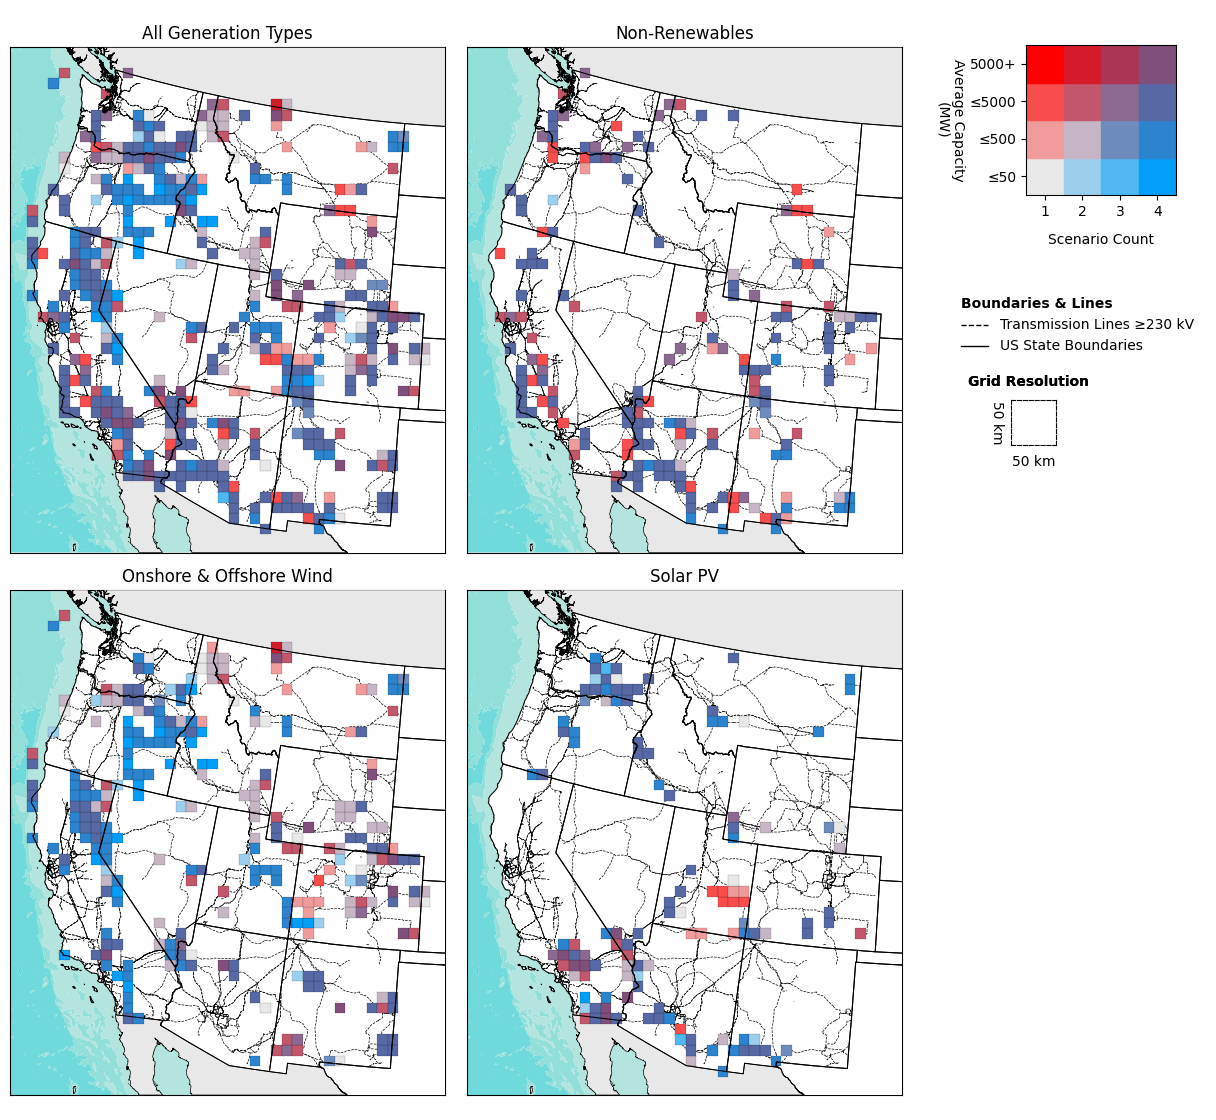

In [8]:

# Define the colors
hex_00 = '#E8E8E8'
hex_20 = '#029ef7'
hex_02 = '#ff0000'

color_dict = get_four_bivariate_color_dict(hex_00, hex_20, hex_02)

scenario_list = ['rcp45hotter_ssp5',
                 'rcp45cooler_ssp5',
                 'rcp85hotter_ssp5',
                 'rcp85cooler_ssp5']

gdf_cooler = gdf[gdf.scenario.isin(scenario_list)]

gdf_list = [
    get_analysis(gdf_cooler, tech_list=gdf.tech_simple.unique(), color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Gas CC', 'Gas CT', 'Gas CC (CCS)', 'Biomass (CCS)', 'Coal (CCS)'], color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Wind (Onshore)', 'Wind (Offshore)'], color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Solar PV'], color_dict=color_dict),
]

title_list = ['All Generation Types', 'Non-Renewables' , 'Onshore & Offshore Wind' ,'Solar PV']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 11))

# Plot in 2 rows, each with 2 map-zoom pairs
for i in range(4):
    row = i // 2
    col = (i % 2)

    ax_main = axes[row, col]

    g = gdf_list[i]
    g.plot(color=g['color'], linewidth=0.1, ax=ax_main, edgecolor="k", legend=True, zorder=5)
    
    state.plot(ax=ax_main, color='white', alpha=1, zorder=3)
    state.boundary.plot(ax=ax_main, color='black', alpha=1, zorder=6, lw=.75)    
    na_shape2.plot(ax=ax_main, color='#e8e8e8', alpha=1, zorder=3)
    na_shape2.boundary.plot(ax=ax_main, color='black', zorder=4, lw=.5)
    basemap_wecc.plot(ax=ax_main, color=basemap_wecc.color, zorder=1)
    transmission_230.plot(ax=ax_main, lw=.5, color='black', linestyle='dashed', zorder=4)  
    
    ax_main.set_xlim(xMin, xMax)
    ax_main.set_ylim(yMin, yMax)
    ax_main.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    ax_main.spines['top'].set_visible(True)
    ax_main.spines['right'].set_visible(True)
    ax_main.spines['bottom'].set_visible(True)
    ax_main.spines['left'].set_visible(True)
    ax_main.set_title(title_list[i])

# Leave space on the right for the legend axis
plt.tight_layout(rect=[0, 0, 0.85, 1])  # shrink plot area

# Create new axis for stacked vertical legends
legend_ax = fig.add_axes([0.8, 0, 0.25, 1])  # [left, bottom, width, height]
legend_ax.axis('off')  # Hide frame and ticks

# boundary legend
bound_legend = legend_ax.legend(handles=boundary_legend_elements, title='Boundaries & Lines', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(1, .75), frameon=False,)
legend_ax.add_artist(bound_legend)
box_ax = legend_ax.inset_axes([0.4, .65, .5, .5]) # x, y, width, height (page orientation)
box_ax.set_aspect('equal')


size_ax = legend_ax.inset_axes([0.35, .55, .15, .15]) # x, y, width, height (page orientation)
size_ax.set_aspect('equal')
for spine in size_ax.spines.values():
    spine.set_linestyle('--')

# Set the limits of the axes
size_ax.set_xlim(0, 1)
size_ax.set_ylim(0, 1)
size_ax.set_xticks([])
size_ax.set_xticklabels([])
size_ax.set_yticks([])
size_ax.set_yticklabels([])
size_ax.set_xlabel("50 km", size=10, labelpad=7,)
size_ax.set_ylabel("50 km", rotation=270, labelpad=15, size=10) 
size_ax = legend_ax.legend(title='Grid Resolution', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(.65, .68), frameon=False,)
legend_ax.add_artist(size_ax)


variable_1='Scenario Count'
variable_2="Average Capacity\n(MW)"
color_list = []
for k in color_dict.keys():
    color_list.append(color_dict[k])

# Create a 3x3 grid of colors
grid = np.array(color_list).reshape(4, 4)

# Display the grid
for i in range(4):
    for j in range(4):
        box_ax.add_patch(plt.Rectangle((i, j), 1, 1, color=grid[i, j]))

# Set the limits of the axes
box_ax.set_xlim(0, 4)
box_ax.set_ylim(0, 4)

# Turn off the axis labels
box_ax.set_xticks([.5, 1.5, 2.5, 3.5])
box_ax.set_xticklabels(['1', '2', '3', '4'])
box_ax.set_yticks([.5, 1.5, 2.5, 3.5])
box_ax.set_yticklabels(['≤50', '≤500', '≤5000', '5000+'])

box_ax.set_xlabel(variable_1, size=10, labelpad=10,)
box_ax.set_ylabel(variable_2, rotation=270, labelpad=25, size=10) 

plt.savefig(os.path.join(fig_dir, 'fig6.png'), dpi = 400, bbox_inches = 'tight')
plt.show()

### Supplemental Information Figure 4

/var/folders/zp/6_04pmq97nq_cq_837pfbx200000gn/T/ipykernel_33090/1388265590.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  size_ax = legend_ax.legend(title='Grid Resolution',


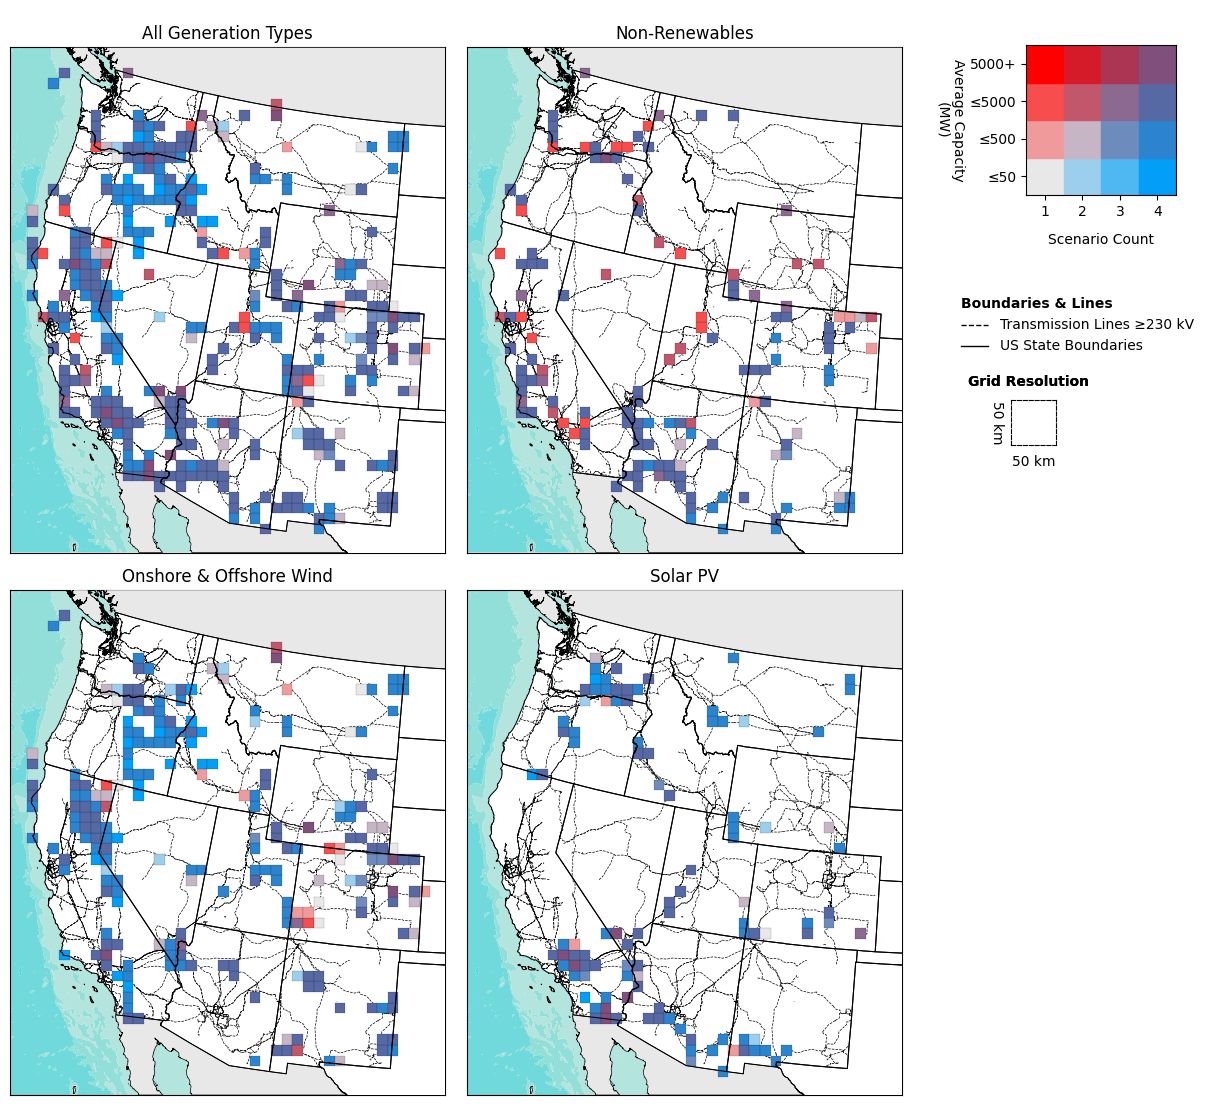

In [8]:
# Define the colors
hex_00 = '#E8E8E8'
hex_20 = '#029ef7'
hex_02 = '#ff0000'


color_dict = get_four_bivariate_color_dict(hex_00, hex_20, hex_02)

scenario_list = ['rcp45hotter_ssp3',
                 'rcp45cooler_ssp3',
                 'rcp85hotter_ssp3',
                 'rcp85cooler_ssp3']

gdf_cooler = gdf[gdf.scenario.isin(scenario_list)]

gdf_list = [
    get_analysis(gdf_cooler, tech_list=gdf.tech_simple.unique(), color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Gas CC', 'Gas CT', 'Gas CC (CCS)', 'Biomass (CCS)', 'Coal (CCS)'], color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Wind (Onshore)', 'Wind (Offshore)'], color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Solar PV'], color_dict=color_dict),
]

title_list = ['All Generation Types', 'Non-Renewables' , 'Onshore & Offshore Wind' ,'Solar PV']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 11))

# Plot in 2 rows, each with 2 map-zoom pairs
for i in range(4):
    row = i // 2
    col = (i % 2)

    ax_main = axes[row, col]

    g = gdf_list[i]
    g.plot(color=g['color'], linewidth=0.1, ax=ax_main, edgecolor="k", legend=True, zorder=5)
    
    state.plot(ax=ax_main, color='white', alpha=1, zorder=3)
    state.boundary.plot(ax=ax_main, color='black', alpha=1, zorder=6, lw=.75)    
    na_shape2.plot(ax=ax_main, color='#e8e8e8', alpha=1, zorder=3)
    na_shape2.boundary.plot(ax=ax_main, color='black', zorder=4, lw=.5)
    basemap_wecc.plot(ax=ax_main, color=basemap_wecc.color, zorder=1)
    transmission_230.plot(ax=ax_main, lw=.5, color='black', linestyle='dashed', zorder=4)  
    
    ax_main.set_xlim(xMin, xMax)
    ax_main.set_ylim(yMin, yMax)
    ax_main.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    ax_main.spines['top'].set_visible(True)
    ax_main.spines['right'].set_visible(True)
    ax_main.spines['bottom'].set_visible(True)
    ax_main.spines['left'].set_visible(True)
    ax_main.set_title(title_list[i])

# Leave space on the right for the legend axis
plt.tight_layout(rect=[0, 0, 0.85, 1])  # shrink plot area

# Create new axis for stacked vertical legends
legend_ax = fig.add_axes([0.8, 0, 0.25, 1])  # [left, bottom, width, height]
legend_ax.axis('off')  # Hide frame and ticks

# boundary legend
bound_legend = legend_ax.legend(handles=boundary_legend_elements, title='Boundaries & Lines', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(1, .75), frameon=False,)
legend_ax.add_artist(bound_legend)
box_ax = legend_ax.inset_axes([0.4, .65, .5, .5]) # x, y, width, height (page orientation)
box_ax.set_aspect('equal')

size_ax = legend_ax.inset_axes([0.35, .55, .15, .15]) # x, y, width, height (page orientation)
size_ax.set_aspect('equal')
for spine in size_ax.spines.values():
    spine.set_linestyle('--')

# Set the limits of the axes
size_ax.set_xlim(0, 1)
size_ax.set_ylim(0, 1)
size_ax.set_xticks([])
size_ax.set_xticklabels([])
size_ax.set_yticks([])
size_ax.set_yticklabels([])
size_ax.set_xlabel("50 km", size=10, labelpad=7,)
size_ax.set_ylabel("50 km", rotation=270, labelpad=15, size=10) 
size_ax = legend_ax.legend(title='Grid Resolution', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(.65, .68), frameon=False,)
legend_ax.add_artist(size_ax)


variable_1='Scenario Count'
variable_2="Average Capacity\n(MW)"
color_list = []
for k in color_dict.keys():
    color_list.append(color_dict[k])

# Create a 3x3 grid of colors
grid = np.array(color_list).reshape(4, 4)

# Display the grid
for i in range(4):
    for j in range(4):
        box_ax.add_patch(plt.Rectangle((i, j), 1, 1, color=grid[i, j]))

# Set the limits of the axes
box_ax.set_xlim(0, 4)
box_ax.set_ylim(0, 4)

# Turn off the axis labels
box_ax.set_xticks([.5, 1.5, 2.5, 3.5])
box_ax.set_xticklabels(['1', '2', '3', '4'])
box_ax.set_yticks([.5, 1.5, 2.5, 3.5])
box_ax.set_yticklabels(['≤50', '≤500', '≤5000', '5000+'])

box_ax.set_xlabel(variable_1, size=10, labelpad=10,)
box_ax.set_ylabel(variable_2, rotation=270, labelpad=25, size=10) 

plt.savefig(os.path.join(fig_dir, 'si_4.png'), dpi = 400, bbox_inches = 'tight')
plt.show()

/var/folders/zp/6_04pmq97nq_cq_837pfbx200000gn/T/ipykernel_33090/850241182.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  size_ax = legend_ax.legend(title='Grid Resolution',


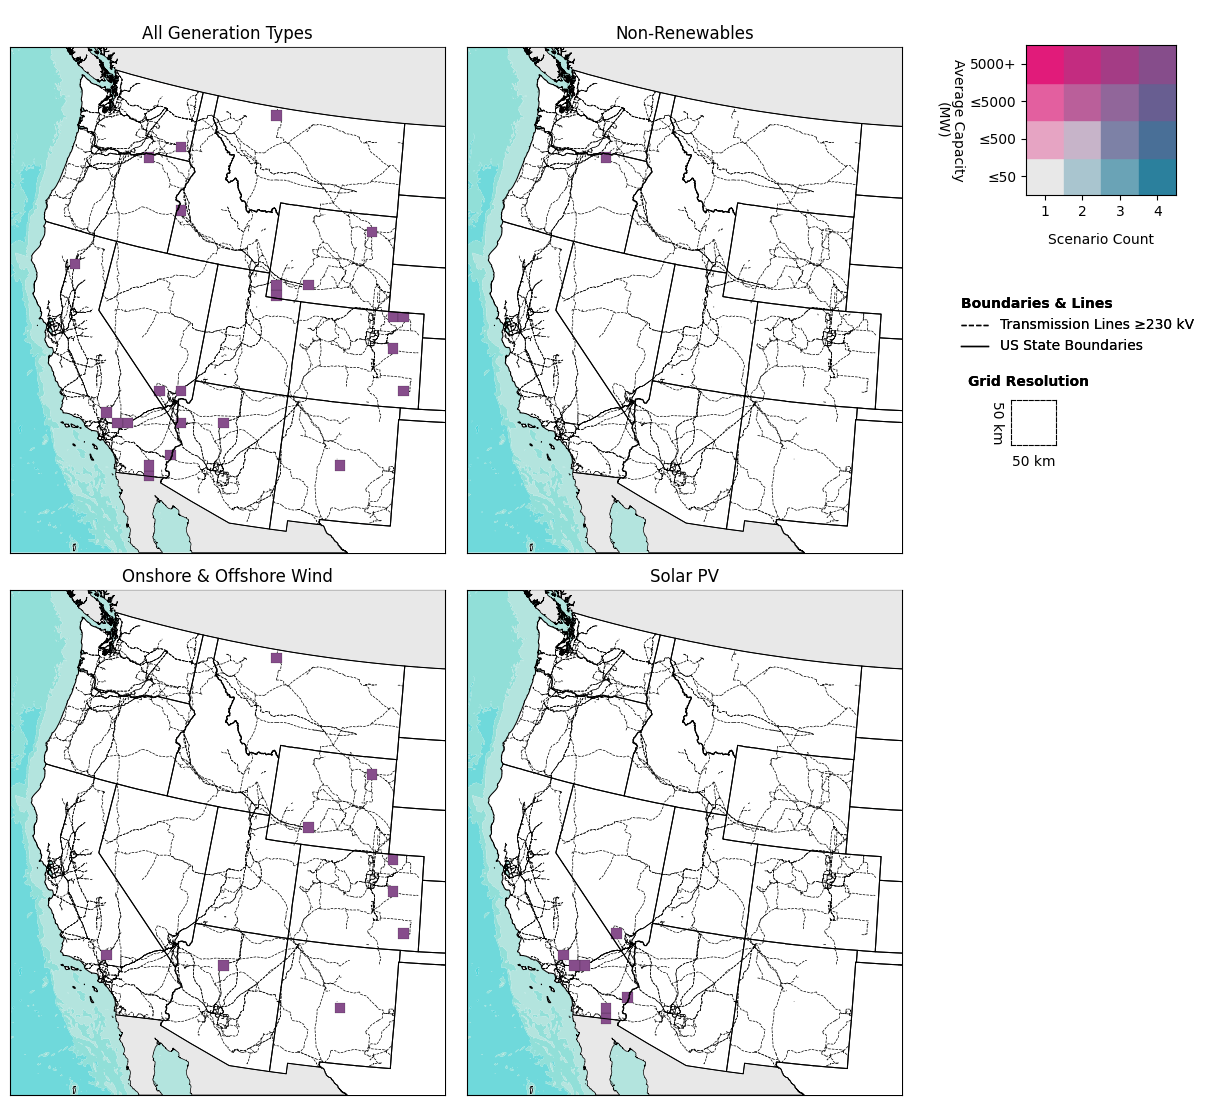

In [9]:
# Define the colors
hex_00 = '#E8E8E8' # tan
hex_20 = '#2B809D' # right
hex_02 = '#E11B7A' # left

scenario_list = ['rcp45hotter_ssp5',
                 'rcp45cooler_ssp5',
                 'rcp85hotter_ssp5',
                 'rcp85cooler_ssp5']

color_dict = get_four_bivariate_color_dict(hex_00, hex_20, hex_02)
gdf_cooler = gdf[gdf.scenario.isin(scenario_list)]

gdf_list = [
    get_analysis(gdf_cooler, tech_list=gdf.tech_simple.unique(), color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Gas CC', 'Gas CT', 'Gas CC (CCS)', 'Biomass (CCS)', 'Coal (CCS)'], color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Wind (Onshore)', 'Wind (Offshore)'], color_dict=color_dict),
    get_analysis(gdf_cooler, tech_list=['Solar PV'], color_dict=color_dict),
]


title_list = ['All Generation Types', 'Non-Renewables' , 'Onshore & Offshore Wind' ,'Solar PV']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 11))

# Plot in 2 rows, each with 2 map-zoom pairs
for i in range(4):
    row = i // 2
    col = (i % 2)

    ax_main = axes[row, col]

    g = gdf_list[i]
    g = g[g.color_index.isin(['33'])]
    g.plot(color=g['color'], linewidth=0.1, ax=ax_main, edgecolor="k", legend=True, zorder=5)
    
    state.plot(ax=ax_main, color='white', alpha=1, zorder=3)
    state.boundary.plot(ax=ax_main, color='black', alpha=1, zorder=6, lw=.75)    
    na_shape2.plot(ax=ax_main, color='#e8e8e8', alpha=1, zorder=3)
    na_shape2.boundary.plot(ax=ax_main, color='black', zorder=4, lw=.5)
    basemap_wecc.plot(ax=ax_main, color=basemap_wecc.color, zorder=1)
    transmission_230.plot(ax=ax_main, lw=.5, color='black', linestyle='dashed', zorder=4)  
    
    ax_main.set_xlim(xMin, xMax)
    ax_main.set_ylim(yMin, yMax)
    ax_main.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    ax_main.spines['top'].set_visible(True)
    ax_main.spines['right'].set_visible(True)
    ax_main.spines['bottom'].set_visible(True)
    ax_main.spines['left'].set_visible(True)
    ax_main.set_title(title_list[i])

# Leave space on the right for the legend axis
plt.tight_layout(rect=[0, 0, 0.85, 1])  # shrink plot area

# Create new axis for stacked vertical legends
legend_ax = fig.add_axes([0.8, 0, 0.25, 1])  # [left, bottom, width, height]
legend_ax.axis('off')  # Hide frame and ticks

# boundary legend
bound_legend = legend_ax.legend(handles=boundary_legend_elements, title='Boundaries & Lines', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(1, .75), frameon=False,)
legend_ax.add_artist(bound_legend)
box_ax = legend_ax.inset_axes([0.4, .65, .5, .5]) # x, y, width, height (page orientation)
box_ax.set_aspect('equal')

# boundary legend
bound_legend = legend_ax.legend(handles=boundary_legend_elements, title='Boundaries & Lines', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(1, .75), frameon=False,)
legend_ax.add_artist(bound_legend)

size_ax = legend_ax.inset_axes([0.35, .55, .15, .15]) # x, y, width, height (page orientation)
size_ax.set_aspect('equal')
for spine in size_ax.spines.values():
    spine.set_linestyle('--')

# Set the limits of the axes
size_ax.set_xlim(0, 1)
size_ax.set_ylim(0, 1)
size_ax.set_xticks([])
size_ax.set_xticklabels([])
size_ax.set_yticks([])
size_ax.set_yticklabels([])
size_ax.set_xlabel("50 km", size=10, labelpad=7,)
size_ax.set_ylabel("50 km", rotation=270, labelpad=15, size=10) 
size_ax = legend_ax.legend(title='Grid Resolution', 
                                title_fontproperties={'weight':'bold', 'size':10},
                              alignment='left',
                              bbox_to_anchor=(.65, .68), frameon=False,)
legend_ax.add_artist(size_ax)


variable_1='Scenario Count'
variable_2="Average Capacity\n(MW)"
color_list = []
for k in color_dict.keys():
    color_list.append(color_dict[k])

# Create a 3x3 grid of colors
grid = np.array(color_list).reshape(4, 4)

# Display the grid
for i in range(4):
    for j in range(4):
        box_ax.add_patch(plt.Rectangle((i, j), 1, 1, color=grid[i, j]))

# Set the limits of the axes
box_ax.set_xlim(0, 4)
box_ax.set_ylim(0, 4)

# Turn off the axis labels
# Turn off the axis labels
box_ax.set_xticks([.5, 1.5, 2.5, 3.5])
box_ax.set_xticklabels(['1', '2', '3', '4'])
box_ax.set_yticks([.5, 1.5, 2.5, 3.5])
box_ax.set_yticklabels(['≤50', '≤500', '≤5000', '5000+'])

box_ax.set_xlabel(variable_1, size=10, labelpad=10,)
box_ax.set_ylabel(variable_2, rotation=270, labelpad=25, size=10) 

plt.show()